# Module 01 — Data Representation

Most scikit-learn errors are not modelling errors. They are **shape, dtype and
type-of-target errors**, and they occur before any learning happens. This
module makes those failure modes boring by making the representation explicit.

### Learning objectives

1. Use all three dataset families (`load_*`, `fetch_*`, `make_*`) and know when
   each is the right choice.
2. Read a `Bunch` and know when to bypass it with `return_X_y` / `as_frame`.
3. Reason about dtypes: why `object` columns break estimators, when to use
   pandas `category`, and what `float32` buys you.
4. Use `type_of_target` to diagnose "why does sklearn think this is a
   regression problem".
5. Work with sparse matrices without accidentally densifying 40 GB.
6. Profile a new table quickly enough that you actually do it.

In [31]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

from skmastery import describe_frame, load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

## 1. The three dataset families

| Prefix | Where the data lives | Use it for |
|---|---|---|
| `load_*` | shipped inside the wheel | instant, offline, tiny — smoke tests and teaching |
| `fetch_*` | downloaded and cached to `~/scikit_learn_data` | realistic size, needs network once |
| `make_*` | generated on the fly from a known process | **you control the ground truth** |

The third family is the one experienced practitioners use most and beginners
use least. When you generate the data you know the true number of informative
features, the true noise level, the true cluster count — so you can check
whether a method *recovers* what you put in. That is how you build intuition
about when a method works, which is not something a real dataset can tell you.

In [7]:
from sklearn.datasets import load_diabetes, make_classification, make_regression

# load_* : a Bunch, which is a dict that also allows attribute access.
bunch = load_diabetes()
print(type(bunch).__name__, "keys:", list(bunch.keys()))
print("data", bunch.data.shape, "| target", bunch.target.shape)
print("feature_names:", bunch.feature_names)
print("\nFirst 400 chars of DESCR:\n", bunch.DESCR[:400].strip())

Bunch keys: ['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module']
data (442, 10) | target (442,)
feature_names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 400 chars of DESCR:
 .. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Att


In [11]:
# Three ways to unpack the same loader. Pick deliberately.
X_arr, y_arr = load_diabetes(return_X_y=True)                   # numpy, fastest
X_df, y_ser = load_diabetes(return_X_y=True, as_frame=True)     # pandas, named
frame = load_diabetes(as_frame=True).frame                      # one frame, X+y - Also adds the Target column to the frame

print(type(X_arr).__name__, type(X_df).__name__, type(frame).__name__)
print(X_arr[:3])
print(X_df.head(3))
print(frame.head(3))


ndarray DataFrame DataFrame
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]]
        age       sex       bmi        bp        s1        s2        s3        s4        s5        s6
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401 -0.002592  0.019907 -0.017646
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412 -0.039493 -0.068332 -0.092204
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356 -0.002592  0.002861 -0.025930
        age       sex       bmi        bp        s1        s2        s3        s4        s5        s6  target
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401 -0.002

### `make_*`: ground truth you can check against

`make_classification` builds a problem out of `n_informative` genuinely useful
features, `n_redundant` linear combinations of those, and
`n_repeated` + noise columns. Because you specified the split, you can ask
whether your feature-selection method finds it.

In [18]:
X, y, true_coef = make_regression(
    n_samples=400,
    n_features=20,
    n_informative=5,     # only 5 features actually matter
    noise=12.0,
    coef=True,           # return the ground-truth coefficients
    random_state=0,
)
#print("input samples ",X[3,])
#print("output values", y[3,])
#print("make_regression coefficients:",true_coef)

truth = pd.Series(true_coef).round(1)
print("Truly informative features:", truth[truth != 0].to_dict())

from sklearn.linear_model import LassoCV
#print("Lasso coefficients:",LassoCV(cv=5, random_state=0).fit(X, y).coef_)
recovered = pd.Series(LassoCV(cv=5, random_state=0).fit(X, y).coef_).round(1)
comparison = pd.DataFrame({"true": truth, "lasso": recovered})
print(comparison[(comparison.true != 0) | (comparison.lasso.abs() > 0.5)])

# 2. Train a model to "guess" the coefficients
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
print("\n")
# 3. Compare the truth against the model's guess
#print("Ground Truth Coefficients:", true_coef)
#print("LR Model's Estimated Coefs: ", model.coef_)
recovered_coefs_LR = pd.Series(model.coef_).round(1)
comparison_LR = pd.DataFrame({"true": truth,"LR": recovered_coefs_LR})
print(comparison_LR[(comparison_LR.true != 0) | (comparison_LR.LR.abs() > 0.5)])

Truly informative features: {3: 87.1, 5: 71.7, 6: 1.2, 9: 69.8, 19: 59.7}
    true  lasso
1    0.0   -0.6
3   87.1   87.4
5   71.7   70.9
6    1.2    1.6
9   69.8   69.6
11   0.0   -1.0
19  59.7   59.8


    true    LR
1    0.0  -1.2
3   87.1  87.9
5   71.7  71.2
6    1.2   2.0
9   69.8  70.1
10   0.0   0.6
11   0.0  -1.3
15   0.0   0.9
19  59.7  60.3


That is a genuinely useful habit: **before trusting a method on real data,
check it recovers a signal you planted.** If Lasso cannot find five features
out of twenty when you know they are there, it will not find them when you
don't.

### Importance of Ground-Truth Coefficients 
Ground truth coefficients are incredibly valuable for evaluating and debugging machine learning models.Because real-world data is messy, you never truly know the "perfect" formula behind a dataset. You can only guess it using a model. However, with a synthetic dataset, you know the exact truth. This allows you to directly compare your model's predictions against reality

#### Evaluating Accuracy

You can train a LinearRegression model on the data, extract its estimated weights (model.coef_), and compare them directly to the ground truth coefficients. If they are close, your model is working perfectly.

#### Testing Feature Selection ### 

If you set n_features=10 and n_informative=3, scikit-learn will give 7 of the features a ground truth coefficient of 0 (meaning they are completely useless). You can use this to test if algorithms like Lasso Regression or feature-selection loops successfully identify and ignore those 7 useless columns.

#### Sample Generators

**make_blobs** creates a multiclass dataset by allocating each class to one normally-distributed cluster of points. It provides control over the centers and standard deviations of each cluster. This dataset is used to demonstrate clustering.

**make_classification** also creates multiclass datasets but specializes in introducing noise by way of: correlated, redundant and uninformative features; multiple Gaussian clusters per class; and linear transformations of the feature space.

**make_circles** and **make_moons** generate 2D binary classification datasets that are challenging to certain algorithms (e.g., centroid-based clustering or linear classification), including optional Gaussian noise. They are useful for visualization. make_circles produces Gaussian data with a spherical decision boundary for binary classification, while make_moons produces two interleaving half-circles.

**make_regression** produces regression targets as an optionally-sparse random linear combination of random features, with noise. Its informative features may be uncorrelated, or low rank (few features account for most of the variance).





findfont: Failed to find font weight 600, now using 700.


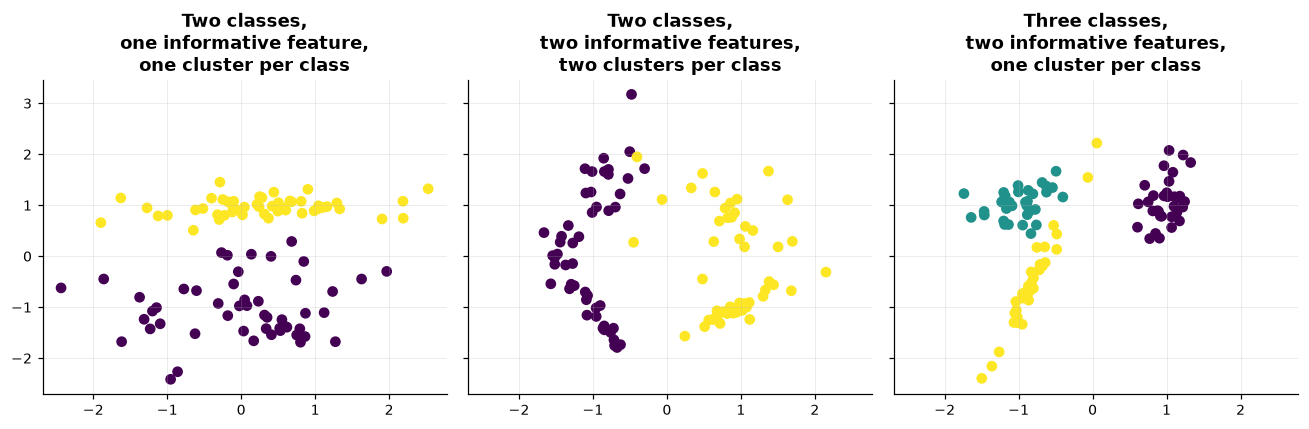

In [20]:
# make_classification example
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)
titles = ["Two classes,\none informative feature,\none cluster per class",
          "Two classes,\ntwo informative features,\ntwo clusters per class",
          "Three classes,\ntwo informative features,\none cluster per class"]
params = [
    {"n_informative": 1, "n_clusters_per_class": 1, "n_classes": 2},
    {"n_informative": 2, "n_clusters_per_class": 2, "n_classes": 2},
    {"n_informative": 2, "n_clusters_per_class": 1, "n_classes": 3}
]

for i, param in enumerate(params):
    X, Y = make_classification(n_features=2, n_redundant=0, random_state=1, **param)
    axs[i].scatter(X[:, 0], X[:, 1], c=Y)
    axs[i].set_title(titles[i])

plt.tight_layout()
plt.show()

findfont: Failed to find font weight 600, now using 700.


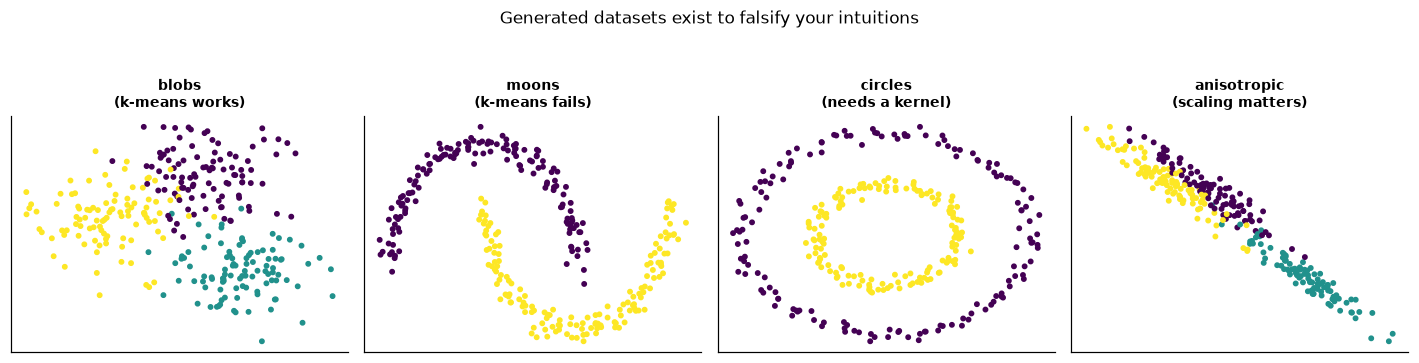

In [19]:
# Other generators worth knowing, and what each is for.
from sklearn.datasets import (
    make_blobs,
    make_circles,
    make_moons,
    make_s_curve,
)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.1))
for ax, (name, (Xg, yg)) in zip(
    axes,
    {
        "blobs\n(k-means works)": make_blobs(n_samples=300, centers=3, random_state=0),
        "moons\n(k-means fails)": make_moons(n_samples=300, noise=0.06, random_state=0),
        "circles\n(needs a kernel)": make_circles(n_samples=300, noise=0.04, factor=0.5, random_state=0),
        "anisotropic\n(scaling matters)": (
            make_blobs(n_samples=300, centers=3, random_state=0)[0] @ [[0.6, -0.7], [-0.4, 0.9]],
            make_blobs(n_samples=300, centers=3, random_state=0)[1],
        ),
    }.items(),
):
    ax.scatter(Xg[:, 0], Xg[:, 1], c=yg, s=8, cmap="viridis")
    ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Generated datasets exist to falsify your intuitions", y=1.05, fontsize=11)
plt.tight_layout()

## 2. dtypes: where things quietly go wrong

scikit-learn's numeric estimators ultimately want a float array. The path from
your DataFrame to that array is where the errors live.

In [21]:
credit = load_credit_risk()
describe_frame(credit)

,dtype,missing_%,n_unique,sample
column,,,,
application_id,str,0.00,12000,"APP000000, APP000001, APP000002, …"
application_month,str,0.00,36,"2022-11, 2024-12, 2023-11, …"
age,int64,0.00,67,"21, 42, 53, …"
employment_years,float64,13.89,296,"1.4, 9.7, 9.6, …"
annual_income,float64,1.68,1005,"22000.0, 38300.0, 45100.0, …"
loan_amount,float64,0.00,714,"22600.0, 13300.0, 17600.0, …"
term_months,int64,0.00,5,"12, 24, 36, 48, 60"
interest_rate,float64,0.00,861,"15.35, 14.15, 14.02, …"
debt_to_income,float64,0.00,5598,"0.4214, 0.2295, 0.2291, …"


Four dtype situations, and what each means for you:

| What you have | What sklearn does | What to do |
|---|---|---|
| `int64` / `float64` | uses it directly | nothing |
| `bool` | casts to 0/1 | nothing |
| `object` / `str` | **raises** on numeric estimators | encode it (Module 02) |
| `category` | raises *unless* the estimator declares support | encode, or use a native-categorical estimator |

That last row is the interesting one. `HistGradientBoostingClassifier`,
LightGBM and CatBoost can consume categoricals natively — no one-hot, no
ordinal codes, no cardinality explosion. That is often a better answer than
encoding, and it is invisible if you only ever reach for `OneHotEncoder`.

In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

X = credit.drop(columns=["default", "application_id", "collections_flag"])
y = credit["default"]

try:
    LogisticRegression().fit(X, y)
except ValueError as e:
    print("LogisticRegression on raw mixed types ->", str(e).split("\n")[0][:110])

# HistGradientBoosting can be told to treat object/category columns natively.
X_cat = X.copy()
for col in X_cat.select_dtypes(include=["object", "string"]).columns:
    X_cat[col] = X_cat[col].astype("category")

hgb = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0)
hgb.fit(X_cat, y)
print("\nHistGradientBoosting with native categoricals -> fitted, no encoding at all")
print("categorical columns detected:", int(np.sum(hgb.is_categorical_)))

LogisticRegression on raw mixed types -> could not convert string to float: '2022-11'

HistGradientBoosting with native categoricals -> fitted, no encoding at all
categorical columns detected: 6


### Memory: `float64` is the default and is usually twice what you need

In [23]:
big = np.random.default_rng(0).normal(size=(200_000, 60))
print(f"float64 : {big.nbytes / 1e6:6.1f} MB")
print(f"float32 : {big.astype(np.float32).nbytes / 1e6:6.1f} MB")

# Most sklearn estimators accept float32 and keep it (check `dtype` in the
# docstring's `check_array` call). Tree ensembles internally use float32 anyway.
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=5, random_state=0).fit(big[:2000].astype(np.float32), big[:2000, 0])
print("\nfitted on float32 without complaint:", rf.n_features_in_, "features")

float64 :   96.0 MB
float32 :   48.0 MB

fitted on float32 without complaint: 60 features


### pandas `category` for cardinality, not just tidiness

In [24]:
mem_object = credit["purpose"].memory_usage(deep=True)
mem_category = credit["purpose"].astype("category").memory_usage(deep=True)
print(f"purpose as string   : {mem_object / 1e3:7.1f} KB")
print(f"purpose as category : {mem_category / 1e3:7.1f} KB  ({mem_object / mem_category:.1f}x smaller)")

# The other benefit: the category list is *part of the dtype*, so an unseen
# level at scoring time is detectable rather than silently absent.
cat = pd.Categorical(credit["purpose"])
print("\nknown levels:", list(cat.categories))

purpose as string   :   748.5 KB
purpose as category :    12.6 KB  (59.6x smaller)

known levels: ['auto', 'debt_consolidation', 'home_improvement', 'major_purchase', 'medical', 'other', 'small_business']


## 3. `type_of_target`: the function that ends the confusion

"Why does `cross_val_score` want a regression metric?" is nearly always
because sklearn inferred a different target type from the one you meant.
`type_of_target` tells you what it inferred.

In [25]:
from sklearn.utils.multiclass import type_of_target

cases = {
    "binary ints": np.array([0, 1, 1, 0]),
    "binary floats": np.array([0.0, 1.0, 1.0, 0.0]),
    "binary strings": np.array(["good", "bad", "bad", "good"]),
    "multiclass": np.array([0, 1, 2, 1]),
    "multiclass-strings": np.array(["a", "b", "c", "b"]),
    "continuous": np.array([0.1, 0.7, 2.3, 1.1]),
    "continuous but few values": np.array([1.5, 2.5, 1.5, 2.5]),
    "multilabel": np.array([[1, 0, 1], [0, 1, 0]]),
    "multiclass-multioutput": np.array([[1, 2], [0, 3]]),
    "column vector (a common bug)": np.array([[0], [1], [1], [0]]),
}
pd.Series({k: type_of_target(v) for k, v in cases.items()}, name="type_of_target").to_frame()

,type_of_target
binary ints,binary
binary floats,binary
binary strings,binary
multiclass,multiclass
multiclass-strings,multiclass
continuous,continuous
continuous but few values,continuous
multilabel,multilabel-indicator
multiclass-multioutput,multiclass-multioutput
column vector (a common bug),binary


Two rows deserve attention.

- **`continuous but few values` → `multiclass`.** A target of `[1.5, 2.5,
  1.5, 2.5]` is inferred as classification because it has few distinct
  values and no fractional pattern sklearn recognises as continuous. If your
  regression target is coarsely rounded, say so explicitly rather than letting
  inference decide.
- **`column vector` → `multilabel-indicator`** on some shapes and triggers a
  `DataConversionWarning` on others. `y` should be 1-D. `y.ravel()` or
  `y.squeeze()` before you fit.

In [26]:
from sklearn.linear_model import LinearRegression
import warnings

y_2d = np.array([[0], [1], [1], [0]])
X_small = np.arange(8).reshape(4, 2).astype(float)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    LinearRegression().fit(X_small, y_2d)
    print("fit with 2-D y:", [w.category.__name__ for w in caught] or "no warning (silently multi-output)")
print("shape of coef_ :", LinearRegression().fit(X_small, y_2d).coef_.shape, "<- 2-D, i.e. multi-output")
print("shape with 1-D :", LinearRegression().fit(X_small, y_2d.ravel()).coef_.shape)

fit with 2-D y: no warning (silently multi-output)
shape of coef_ : (1, 2) <- 2-D, i.e. multi-output
shape with 1-D : (2,)


## 4. Sparse matrices

Text features, one-hot encodings of high-cardinality columns, and interaction
expansions all produce matrices that are mostly zeros. Storing them densely is
the single most common way to run out of memory in a modelling script.

In [27]:
from sklearn.preprocessing import OneHotEncoder

high_card = pd.DataFrame({"merchant": [f"M{i % 5000:05d}" for i in range(120_000)]})

dense = OneHotEncoder(sparse_output=False).fit_transform(high_card[:5_000])
sparse = OneHotEncoder(sparse_output=True).fit_transform(high_card)

print(f"dense  (5k rows × 5k cols) : {dense.nbytes / 1e6:8.1f} MB")
print(f"sparse (120k rows × 5k cols): {(sparse.data.nbytes + sparse.indices.nbytes + sparse.indptr.nbytes) / 1e6:8.1f} MB")
print(f"\nfull dense equivalent would be : {120_000 * 5_000 * 8 / 1e9:.1f} GB")
print("density:", f"{sparse.nnz / (sparse.shape[0] * sparse.shape[1]):.2e}")

dense  (5k rows × 5k cols) :    200.0 MB
sparse (120k rows × 5k cols):      1.9 MB

full dense equivalent would be : 4.8 GB
density: 2.00e-04


### Which estimators accept sparse input

There is no universal rule, so check rather than assume. The docstring of
`fit` states `X : {array-like, sparse matrix}` when sparse is supported.
As a working heuristic:

- **Sparse-friendly:** linear models with `saga`/`liblinear`, `SGDClassifier`,
  `MultinomialNB`, `TruncatedSVD`, `LinearSVC`, most of `feature_selection`.
- **Dense-only:** `HistGradientBoosting*`, `PCA` (use `TruncatedSVD`),
  `GaussianNB`, `QuadraticDiscriminantAnalysis`, most of `sklearn.manifold`.

The dense-only list is why `sparse_output=False` on your `OneHotEncoder` is
sometimes required — and why you then need `min_frequency`/`max_categories` to
stop the column count exploding.

In [28]:
from sklearn.decomposition import PCA, TruncatedSVD

try:
    PCA(n_components=2).fit(sparse)
except TypeError as e:
    print("PCA on sparse ->", str(e).split("\n")[0][:100])

svd = TruncatedSVD(n_components=2, random_state=0).fit(sparse)
print("TruncatedSVD on sparse -> OK, explained variance:", svd.explained_variance_ratio_.round(4))

TruncatedSVD on sparse -> OK, explained variance: [0.0002 0.0002]


## 5. Missing values: representation, not strategy

Strategy is Module 02. Representation is here, because getting it wrong
produces silent nonsense rather than an error.

- `np.nan` is the canonical missing marker. It is a **float**, so a column
  with any missing value cannot be `int64` (unless you use pandas' nullable
  `Int64`).
- `None` in an `object` column is *not* `np.nan` and comparisons behave
  differently.
- Sentinel values (`-999`, `-1`, `9999`, empty string, `"NA"`, `"unknown"`)
  are the real-world hazard: they are numerically valid, so nothing raises,
  and your model happily learns that income of −999 predicts default.

In [29]:
dirty = pd.DataFrame(
    {
        "income": [45_000, -999, 82_000, 9999999, np.nan],
        "score": [710, 640, -1, 800, 690],
        "status": ["active", "", "active", "unknown", None],
    }
)

print("pandas thinks this is missing:")
print(dirty.isna().sum().to_string())

print("\nBut look at the distributions:")
print(dirty[["income", "score"]].describe().loc[["min", "max"]].to_string())

pandas thinks this is missing:
income    1
score     0
status    1

But look at the distributions:
        income  score
min     -999.0   -1.0
max  9999999.0  800.0


In [30]:
# A cheap, effective sentinel sniffer to run on every new table.
def sniff_sentinels(df: pd.DataFrame, suspects=(-1, -999, -9999, 0, 999, 9999, 99999)) -> pd.DataFrame:
    rows = []
    for col in df.select_dtypes("number").columns:
        s = df[col]
        for v in suspects:
            n = int((s == v).sum())
            if n and n / len(s) > 0.005:
                rows.append({"column": col, "value": v, "count": n, "share": round(n / len(s), 4)})
    # also flag values far outside the bulk of the distribution
    for col in df.select_dtypes("number").columns:
        s = df[col].dropna()
        if len(s) > 10:
            q1, q99 = s.quantile([0.01, 0.99])
            extreme = int(((s < q1 - 10 * (q99 - q1)) | (s > q99 + 10 * (q99 - q1))).sum())
            if extreme:
                rows.append({"column": col, "value": "far-outlier", "count": extreme, "share": round(extreme / len(s), 4)})
    return pd.DataFrame(rows)


sniff_sentinels(dirty)

,column,value,count,share
0,income,-999,1,0.2
1,score,-1,1,0.2


In [31]:
# On the (clean-ish) credit data it should find little -- which is the point:
# the function is worth running precisely because it usually returns nothing.
sniff_sentinels(credit)

,column,value,count,share
0,n_open_accounts,0,124,0.0103
1,n_delinq_2yr,0,11148,0.9290
2,collections_flag,0,10401,0.8668
3,default,0,10409,0.8674


> 💼 **Consulting lens.** Sentinel encoding is a *data contract* failure, not a
> modelling failure, and the fix belongs upstream. When you find one, the
> useful output of the engagement is not the imputer you wrote — it is the
> note to the source-system owner. Models built on undocumented sentinels are
> the most common cause of "it worked in the POC and not in production".

## 6. Which estimators tolerate NaN natively

Since 1.1 a growing set handles missing values without an imputer, by learning
a default direction at each split. Knowing the list saves you from imputing
where imputation destroys information.

In [32]:
from sklearn.utils import all_estimators
from sklearn.utils.validation import check_array

def handles_nan(cls) -> bool:
    try:
        est = cls()
        return bool(est.__sklearn_tags__().input_tags.allow_nan)
    except Exception:
        return False


nan_ok = sorted(
    name
    for name, cls in all_estimators()
    if name.startswith(("Hist", "Random", "Extra", "Simple", "Iterative", "KNN", "Decision", "Bagging", "MissingInd", "Quantile"))
    and handles_nan(cls)
)
print("Estimators that accept NaN directly (subset):")
for n in nan_ok:
    print("  ", n)

Estimators that accept NaN directly (subset):
   BaggingClassifier
   BaggingRegressor
   DecisionTreeClassifier
   DecisionTreeRegressor
   ExtraTreeClassifier
   ExtraTreeRegressor
   ExtraTreesClassifier
   ExtraTreesRegressor
   HistGradientBoostingClassifier
   HistGradientBoostingRegressor
   KNNImputer
   MissingIndicator
   QuantileTransformer
   RandomForestClassifier
   RandomForestRegressor
   RandomTreesEmbedding
   SimpleImputer


In [33]:
# Demonstrated: HistGradientBoosting on the raw credit data, missing values and all.
from sklearn.model_selection import cross_val_score

X_nan = X_cat  # still has NaN in employment_years / annual_income / credit_score
print("NaN present:", int(X_nan.isna().sum().sum()))
scores = cross_val_score(
    HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0),
    X_nan, y, cv=3, scoring="roc_auc",
)
print(f"ROC AUC without any imputation: {scores.mean():.4f} ± {scores.std():.4f}")

NaN present: 3230
ROC AUC without any imputation: 0.7504 ± 0.0186


## 7. A profiling routine worth keeping

The reason people skip data profiling is that it takes twenty cells. Here it
takes one. Steal this.

In [37]:
def profile(df: pd.DataFrame, target: str | None = None) -> None:
    n, p = df.shape
    print(f"shape: {n:,} rows × {p} columns    memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
    dupes = int(df.duplicated().sum())
    print(f"duplicate rows: {dupes:,}")
    const = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    if const:
        print(f"constant columns: {const}")
    ids = [c for c in df.columns if df[c].nunique() == n and n > 20]
    if ids:
        print(f"candidate identifiers (drop before modelling): {ids}")
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if len(miss):
        print("\nmissingness:")
        print((miss * 100).round(2).to_string())
    if target and target in df:
        t = df[target]
        print(f"\ntarget '{target}': type_of_target={type_of_target(t)}")
        if type_of_target(t) in {"binary", "multiclass"}:
            vc = t.value_counts(normalize=True).round(4)
            print(vc.to_string())
            print(f"imbalance ratio: {vc.max() / vc.min():.1f} : 1")
        else:
            print(t.describe().round(2).to_string())


profile(credit, target="default")


shape: 12,000 rows × 20 columns    memory: 6.0 MB
duplicate rows: 0
candidate identifiers (drop before modelling): ['application_id']

missingness:
employment_years    13.89
credit_score        11.34
annual_income        1.68

target 'default': type_of_target=binary
default
0    0.8674
1    0.1326
imbalance ratio: 6.5 : 1


In [38]:
# Missingness co-occurrence: is it random, or structured?
miss_mat = credit.isna()
cols = miss_mat.columns[miss_mat.any()]
print("Missingness by employment_type (is it MAR or MNAR?):")
print(
    credit.groupby("employment_type")[list(cols)]
    .apply(lambda g: g.isna().mean())
    .round(3)
    .to_string()
)

Missingness by employment_type (is it MAR or MNAR?):
                 employment_years  annual_income  credit_score
employment_type                                               
contract                    0.023          0.018         0.119
retired                     0.032          0.015         0.114
salaried                    0.029          0.017         0.115
self_employed               0.622          0.017         0.104
unemployed                  0.039          0.016         0.102


`employment_years` is missing for ~60% of the self-employed and ~3% of
everyone else. That is **missing not at random**: the missingness is itself
informative. Imputing the median and moving on throws away a signal. The right
response is usually to impute *and* add a `MissingIndicator` — which is
exactly what `SimpleImputer(add_indicator=True)` does, and the subject of
Module 02.

---
## Exercises

### Exercise 1.1 — Recover a planted signal

Generate a classification problem with `make_classification`:
2,000 samples, 40 features, 6 informative, 6 redundant, `class_sep=0.8`,
`flip_y=0.03`, `random_state=0`. Then:

1. Fit an `ExtraTreesClassifier` and rank features by importance.
2. Fit a `LogisticRegression(penalty="l1", solver="saga")` and rank by
   `|coef|`.
3. `make_classification` places the informative features first, so the truth
   is "indices 0–5 informative, 6–11 redundant". How many of the top 6 from
   each method are genuinely informative? Which method is fooled by the
   redundant features, and why?

model trained successfully on synthetic dataset: <bound method ClassifierMixin.score of ExtraTreesClassifier()>
1. Feature 31 (0.1324)
2. Feature 1 (0.0859)
3. Feature 32 (0.0805)
4. Feature 28 (0.0492)
5. Feature 15 (0.0445)
6. Feature 0 (0.0419)
7. Feature 13 (0.0384)
8. Feature 4 (0.0346)
9. Feature 35 (0.0285)
10. Feature 26 (0.0270)
11. Feature 2 (0.0251)
12. Feature 39 (0.0250)
13. Feature 17 (0.0150)
14. Feature 16 (0.0148)
15. Feature 37 (0.0147)
16. Feature 23 (0.0146)
17. Feature 24 (0.0146)
18. Feature 25 (0.0145)
19. Feature 9 (0.0144)
20. Feature 33 (0.0141)
21. Feature 18 (0.0140)
22. Feature 21 (0.0140)
23. Feature 5 (0.0139)
24. Feature 36 (0.0139)
25. Feature 34 (0.0138)
26. Feature 6 (0.0137)
27. Feature 38 (0.0137)
28. Feature 19 (0.0137)
29. Feature 27 (0.0136)
30. Feature 29 (0.0136)
31. Feature 22 (0.0136)
32. Feature 8 (0.0136)
33. Feature 7 (0.0135)
34. Feature 30 (0.0135)
35. Feature 12 (0.0133)
36. Feature 10 (0.0131)
37. Feature 20 (0.0131)
38. Feature 11 (0.

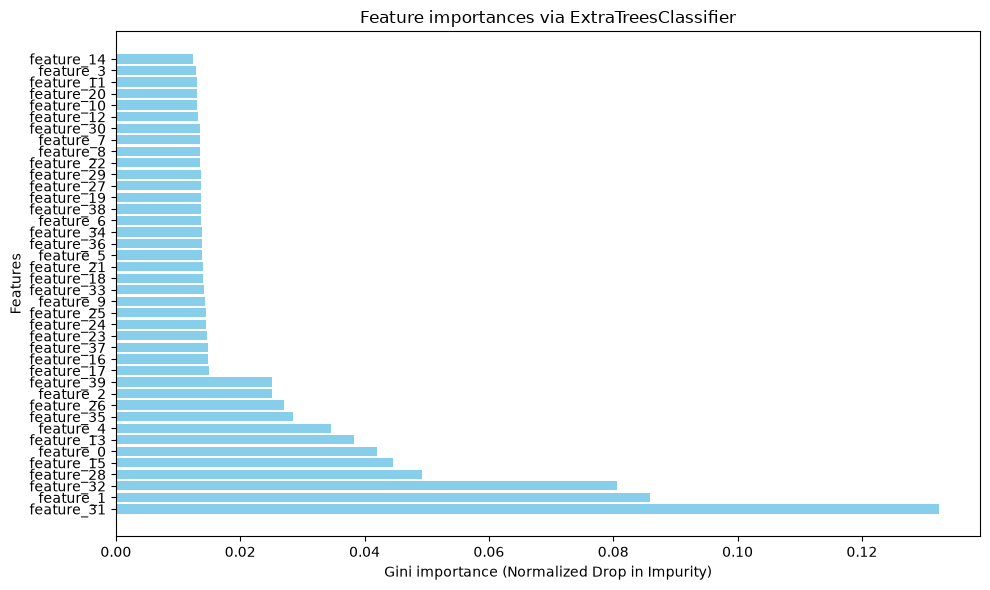

In [ ]:
# Generate a classification problem with make_classification:
# 2,000 samples, 40 features, 6 informative, 6 redundant, class_sep=0.8, flip_y=0.03, 
#  random_state=0. Then:
# Fit an ExtraTreesClassifier and rank features by importance.
# Fit a LogisticRegression(penalty="l1", solver="saga") and rank by |coef|.
from sklearn.datasets import make_classification
import os, re, json, getpass, warnings
import numpy as np, pandas as pd, shap
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
# Generate classification dataset
X, y = make_classification(n_samples=2000, n_features=40,n_informative=6,
                           n_redundant=6,class_sep=0.8,flip_y=0.03,random_state=0)
# Create feature names
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_df,y,test_size=0.2, random_state=0)

# Initialize and train an ExtraTreesClassifier and rank features by importance
model = ExtraTreesClassifier()
model.fit(X_train,y_train)
print("model trained successfully on synthetic dataset:",model.score)
# extract feature importances and sort them descending
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]
# Print the ranked features
for f in range(X.shape[1]):
    print(f"{f+1}. Feature {indices[f]} ({importances[indices[f]]:.4f})")
# plot the importances
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)),sorted_importances,align='center',color='skyblue')
plt.yticks(range(len(indices)),sorted_features)
plt.gca().invert_yaxis # highest importance on top
plt.xlabel("Gini importance (Normalized Drop in Impurity)")
plt.ylabel("Features")
plt.title('Feature importances via ExtraTreesClassifier')
plt.tight_layout()
plt.show()

In [26]:
# Normalize SHAP output to: (n_samples, n_features)
if isinstance(shap_values, list):
    shap_values_for_class_1 = np.asarray(shap_values[1])
else:
    shap_array = np.asarray(shap_values)
    if shap_array.ndim == 3:
        # Shape: (samples, features, classes)
        shap_values_for_class_1 = shap_array[:, :, 1]
    elif shap_array.ndim == 2:
        shap_values_for_class_1 = shap_array
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_array.shape}")

print("SHAP values shape:", shap_values_for_class_1.shape)

global_importance = np.mean(
    np.abs(shap_values_for_class_1),
    axis=0,
)

global_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP": global_importance,
}).sort_values("Mean Absolute SHAP", ascending=False)

print("\nGlobal Feature Importance (Mean Absolute SHAP):")
display(global_importance_df)

SHAP values shape: (400, 40)

Global Feature Importance (Mean Absolute SHAP):


,Feature,Mean Absolute SHAP
31,feature_31,0.091891
1,feature_1,0.053897
32,feature_32,0.052571
28,feature_28,0.036081
0,feature_0,0.028544
15,feature_15,0.028326
4,feature_4,0.024817
13,feature_13,0.024620
26,feature_26,0.013069
35,feature_35,0.009598


A **SHAP base value** is the average prediction of a machine learning model across a background dataset, acting as the model's default guess before looking at any specific data point. 

**How the Base Value Works**
Starting Point: It is the baseline number shown at the start of visual explanations like force plots or waterfall plots.

**Feature Impact:** Individual feature values push the final prediction higher (positive) or lower (negative) starting from this baseline.

**The Additive Rule:** The base value plus the sum of all feature SHAP values equals the final model prediction for that specific row. 

**Base Value by Model Type**

**Regression:** Equal to **the average value of the target variable** in your dataset (such as the mean house price).

**Classification:** Equal to **the average probability or log-odds of the positive class** (such as the percentage of positive cases in the training data)

### Additivity Property Assertion

The additivity property guarantees that the sum of the SHAP values for all features, plus the `base_value`, equals the model's raw output (e.g., `model.predict_proba` before the sigmoid, or `model.decision_function`). This ensures that the explanation completely accounts for the model's output for each individual prediction.

Global importance, on the other hand, is the average impact a feature has across *all* predictions. It tells you which features are generally important, but it doesn't explain *why* any single prediction was made. For an individual case, a globally important feature might have little to no impact, or its impact might be in the opposite direction (lowering the score) compared to its general trend.

In [27]:
# Get the model's raw output for the positive class (before thresholding)
# For GradientBoostingClassifier, decision_function provides this raw score.
# For ExtraTreesClassifer, this is the raw outpuits from predict_proba
model_raw_output = model.predict_proba(X_test)[:,1] #model.decision_function(X_test) positive class only

# If model_raw_output is 2D (e.g., for multi-class or some binary models),
# we need to select the column corresponding to the positive class.
if model_raw_output.ndim == 2:
    # For binary classification with decision_function, it often returns a single column
    # but if it returns two, the second is for the positive class.
    model_raw_output_for_class_1 = model_raw_output[:, 1] if model_raw_output.shape[1] > 1 else model_raw_output[:, 0]
else:
    # If it's 1D, it's already the raw output for the positive class.
    model_raw_output_for_class_1 = model_raw_output
#print(f"Model Raw Output: {model_raw_output_for_class_1}")
# Calculate the sum of SHAP values for each instance
sum_of_shap_contributions = np.sum(shap_values_for_class_1, axis=1)

# Calculate the predicted output from SHAP values (base_value + sum of contributions)
shap_predicted_output = base_value_scalar + sum_of_shap_contributions # Use base_value_scalar here
if shap_predicted_output.ndim == 2:
    shap_predicted_output = shap_predicted_output[:, 1]  # or the correct class index
#print(f"Sum of SHAP Contributions: {sum_of_shap_contributions}\n ")
#print(f"Sum of SHAP Predicted Output: {shap_predicted_output} \n ")
# Calculate the difference (error) between model's raw output and SHAP's predicted output
errors = np.abs(model_raw_output_for_class_1 - shap_predicted_output)

# Define a tolerance for floating point comparisons
tolerance = 1e-4 # Adjust as needed

# Assert additivity
max_error = np.max(errors)

#print(f"Errors: {errors} \n \
print(f"  Max Error: {max_error} ")
print(f"Maximum error in additivity property: {max_error:.6f}")

if max_error > tolerance:
    raise AssertionError(f"Additivity property check failed! Max error {max_error:.6f} exceeds tolerance {tolerance}.")
else:
    print(f"Additivity property holds within tolerance ({tolerance}).")

  Max Error: 1.5993040225481536e-12 
Maximum error in additivity property: 0.000000
Additivity property holds within tolerance (0.0001).


In [28]:
# Calculate mean absolute SHAP values for global importance
global_importance = np.mean(np.abs(shap_values_for_class_1), axis=0)

# Create a DataFrame for better display
global_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Absolute SHAP': global_importance
})

# Sort by importance
global_importance_df = global_importance_df.sort_values(by='Mean Absolute SHAP', ascending=False)

print("\nGlobal Feature Importance (Mean Absolute SHAP):")
display(global_importance_df)


Global Feature Importance (Mean Absolute SHAP):


,Feature,Mean Absolute SHAP
31,feature_31,0.091891
1,feature_1,0.053897
32,feature_32,0.052571
28,feature_28,0.036081
0,feature_0,0.028544
15,feature_15,0.028326
4,feature_4,0.024817
13,feature_13,0.024620
26,feature_26,0.013069
35,feature_35,0.009598


In [29]:
# Find the index of the highest-scoring case in the test set
highest_score_idx = np.argmax(model_raw_output_for_class_1)

# Get the feature values for this case
case_features = X_test.iloc[highest_score_idx]

# Get the SHAP values for this case
case_shap_values = shap_values_for_class_1[highest_score_idx]

# Get the model's raw output for this case
case_raw_output = model_raw_output_for_class_1[highest_score_idx]

print(f"\n--- Local Explanation for Highest-Scoring Case (Index: {highest_score_idx}) ---")
print(f"Model's Raw Output for this case: {case_raw_output:.4f}")
print(f"Base Value: {base_value_scalar:.4f}\n") # Use base_value_scalar

print("Feature | Value | SHAP Contribution | Direction")
print("---------------------------------------------------")
for i, feature in enumerate(feature_names):
    value = case_features[feature]
    shap_contribution = case_shap_values[i]
    direction = 'raised score' if shap_contribution > 0 else 'lowered score'
    print(f"{feature:<9} | {value:<5.2f} | {shap_contribution:<17.4f} | {direction}")

print("---------------------------------------------------")
# Verify additivity for this specific case
local_shap_sum = np.sum(case_shap_values)
local_additivity_check = base_value_scalar + local_shap_sum # Use base_value_scalar
print(f"Sum of SHAP contributions + Base Value: {local_additivity_check:.4f}")
print(f"Difference (Model Output - SHAP Sum + Base Value): {case_raw_output - local_additivity_check:.6f}")


--- Local Explanation for Highest-Scoring Case (Index: 171) ---
Model's Raw Output for this case: 0.9700
Base Value: 0.4969

Feature | Value | SHAP Contribution | Direction
---------------------------------------------------
feature_0 | -2.73 | 0.0049            | raised score
feature_1 | 0.21  | 0.0376            | raised score
feature_2 | 2.76  | -0.0024           | lowered score
feature_3 | -0.14 | 0.0007            | raised score
feature_4 | 2.60  | 0.0252            | raised score
feature_5 | -0.68 | 0.0019            | raised score
feature_6 | 0.71  | -0.0005           | lowered score
feature_7 | -2.16 | 0.0031            | raised score
feature_8 | -0.11 | 0.0042            | raised score
feature_9 | -0.74 | 0.0013            | raised score
feature_10 | 1.78  | -0.0023           | lowered score
feature_11 | -0.89 | 0.0013            | raised score
feature_12 | 0.25  | 0.0030            | raised score
feature_13 | -2.12 | 0.0372            | raised score
feature_14 | -0.16 | 0.00

### Exercise 1.2 — Diagnose five broken targets

For each of the following, use `type_of_target` and a one-line fit attempt to
say what sklearn will do and how to fix it:

```python
y1 = pd.Series([0, 1, 1, 0]).to_frame()          # DataFrame, not Series
y2 = np.array(["1", "0", "1", "0"])              # numeric-looking strings
y3 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) / 1.0   # float class ids
y4 = np.array([[1, 0], [0, 1], [1, 1], [0, 0]])  # ambiguous
y5 = pd.Series([0, 1, 1, np.nan])                # NaN in the target
```

In [36]:
# type_of_target fit attempts
from sklearn.utils.multiclass import type_of_target

cases = {
    "SeriesDataFrame" : pd.Series([0, 1, 1, 0]).to_frame()  ,        # DataFrame, not Series
    "NumericStrings" : np.array(["1", "0", "1", "0"])       ,       # numeric-looking strings
    "FloatIDs" : np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) / 1.0 ,  # float class ids
    "ArraysinArrays" : np.array([[1, 0], [0, 1], [1, 1], [0, 0]]) , # ambiguous
    "BadData" : pd.Series([0, 1, 1, np.nan])            ,    # NaN in the target    
}
# Add a one-line fit attempt
rows = []
for name, y_ in cases.items():
    try:
        t = type_of_target(y_)
    except Exception as e:
        t = f"raises {type(e).__name__}"
    rows.append({"case": name, "type_of_target": t})
pd.DataFrame(rows).set_index("case")



,type_of_target
case,
SeriesDataFrame,binary
NumericStrings,binary
FloatIDs,multiclass
ArraysinArrays,multilabel-indicator
BadData,raises ValueError


### Exercise 1.3 — Sparse budget

The `card_fraud` dataset has a `card_id` column with ~9,000 distinct values.

1. Compute the dense memory footprint of one-hot encoding it for all 60,000
   rows, in GB. Then compute the sparse footprint.
2. One-hot encode it sparsely, hstack it with the numeric columns using
   `scipy.sparse.hstack`, and fit an `SGDClassifier(loss="log_loss")`.
3. Now do the same with `min_frequency=50` on the encoder. How many columns
   survive, and what happened to the AUC? Write two sentences on whether
   `card_id` should be a feature at all.

In [ ]:
# Your code here.

### Exercise 1.4 — Build a data-quality report

Extend the `profile` function above into `data_quality_report(df, target)`
that additionally reports, per column: cardinality ratio (`nunique / n`),
whether the column is near-constant (top value > 95%), skewness for numerics,
and a flag for suspected sentinels. Return a DataFrame sorted so the most
problematic columns are at the top. Run it on all five bundled datasets and
note the worst issue in each.

In [ ]:
# Your code here.

### Exercise 1.5 — MNAR in practice

Using the credit data, compare three treatments of `credit_score`:

- **A:** drop rows where it is missing
- **B:** `SimpleImputer(strategy="median")`
- **C:** `SimpleImputer(strategy="median", add_indicator=True)`

Score each with 5-fold `roc_auc` using a `HistGradientBoostingClassifier`.
Then compute the default rate among rows where `credit_score` is missing
versus present, and explain the ranking you observed. (Treatment A is a trap —
say precisely why.)

In [ ]:
# Your code here.

---
## Takeaways

- `make_*` generators are for **falsifying your own intuitions**; use them
  before trusting a method on real data.
- The dtype of a column determines which estimators can see it. Native
  categorical support (`HistGradientBoosting`, LightGBM, CatBoost) is often
  better than encoding, and is routinely overlooked.
- `type_of_target` resolves nearly every "sklearn misunderstood my labels"
  problem in one line.
- Sparse is not an optimisation, it is a requirement above a few thousand
  one-hot columns — and it constrains which estimators you can use downstream.
- Sentinel-coded missing values are silent and dangerous. Sniff for them.
- Missingness that is structured (MNAR) is a feature, not a nuisance.

**Next:** Module 02 — transformers: scaling, encoding and imputation, and how
each one changes what your model can learn.